<a href="https://colab.research.google.com/github/esthy13/Water-Level-Distribution/blob/main/Water_level_prediction_last__Esther_Giuliano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Water level prediction using ERA5

---

> **Student:** Esther Giuliano  
> **Matricola:** 0001170083  
> **E-mail:** esther.giuliano@studio.unibo.it

## 00. Problem description
Given a set of  5,000  nodes over the Northern Adriatic Sea, defined by varying longitude and latitude (visualized as red spots in image below), you are supposed to infer the water level of these points at each hour in a given range, using a neural network.

The information that can be used to predict these values are:
* **latitude** and **longitude** of the nodes
* the **ephemerides** relative to the sun and the moon at each hour (we consider a single value of the ephemeridies for the whole region). Ephemerides are key predictors of tidal motion and are therefore important for the prediction of water level. The provided values of the ephemerides are already normalized.
* **weather variables** (wind components and pressure) derived from ERA5 dataset (not normalized). Due to the low resolution of ERA5, these values are organized as an array of shape $5 \times 9$ for each hour and each variable. A supporting function is provided to convert a given (latitude, longitude) of a node to the associated index of ERA5 array. Weather variables are important to predict phenomenon such as storm surge: another key component of water level.

For the prediction of the water level at timestamp $t$, it's allowed to use a sequence of any length of the input variables relative to past timesteps, but no future information. The output variable (corresponding to the **water level**) **CANNOT** be used as input to the model, not even for past timestamps.   


## 01. Installing and importing useful libraries

In [1]:
!pip install cartopy

In [2]:
import gdown
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import random
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, LayerNormalization, GRU

In [3]:
# Set random seeds for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
os.environ["KERAS_BACKEND"] = "torch"
tf.test.is_built_with_cuda()
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

## 02. Data Download

In [5]:
# lon.npy
!gdown 19m4hBBrup_Ast_ozGFDmVK-i7N2DUQC5

# lat.npy
!gdown 1wtRof_MQJlE2GNplfbflAPR3cxpmiCeZ

Downloading...
From: https://drive.google.com/uc?id=19m4hBBrup_Ast_ozGFDmVK-i7N2DUQC5
To: /content/lon.npy
100% 20.1k/20.1k [00:00<00:00, 58.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1wtRof_MQJlE2GNplfbflAPR3cxpmiCeZ
To: /content/lat.npy
100% 20.1k/20.1k [00:00<00:00, 51.8MB/s]


In [6]:
# TRAINING DATA

# wl_2010_2020.npy
!gdown 1viecawNSkSEGUvEk7nu7rhKcRd5Q7wgm

# tvec_2010_2019.npy
!gdown 1aBCiXHEWN7ZeIlyj77qNCZ7DHwCUy9LG

# ERA5_adriatic_u10v10sp_2010-2019.npy
!gdown 1wVmxNvCg6Pe9Ol3LGM1NykXVwJiZUdE4

#dist_alt_az_moon-sun_coord13-45_2010-2019_norm.npy
!gdown 1epCvAsWYrCISdcbc2dXZArow5ouhsWjl

Downloading...
From (original): https://drive.google.com/uc?id=1viecawNSkSEGUvEk7nu7rhKcRd5Q7wgm
From (redirected): https://drive.google.com/uc?id=1viecawNSkSEGUvEk7nu7rhKcRd5Q7wgm&confirm=t&uuid=3719b4a1-ec79-4559-aedf-60c42d4ae9ef
To: /content/wl_2010-2020.npy
100% 1.75G/1.75G [00:19<00:00, 90.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1aBCiXHEWN7ZeIlyj77qNCZ7DHwCUy9LG
To: /content/tvec_2010-2019.npy
100% 4.21M/4.21M [00:00<00:00, 20.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1wVmxNvCg6Pe9Ol3LGM1NykXVwJiZUdE4
To: /content/ERA5_adriatic_u10v10sp_2010-2019.npy
100% 94.7M/94.7M [00:01<00:00, 54.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1epCvAsWYrCISdcbc2dXZArow5ouhsWjl
To: /content/dist_alt_az_moon-sun_coord13-45_2010-2019_norm.npy
100% 4.21M/4.21M [00:00<00:00, 28.5MB/s]


In [7]:
# TEST DATA

# wl_2020.npy
!gdown 1NzYayIEoY_JzW9E-38ejnHahNlALlFBn

# tvec_2020.npy
!gdown 1-ZrQDQcID40RBVSGAHqLTN0P_wr2U6_Q

# ERA5_adriatic_u10v10_2020.npy
!gdown 13q1PVFDcOTujx_r4fMPKxkJeMw4fAt5j

# dist_alt_az_moon-sun_coord13-45_2020_norm.npy
!gdown 1osjH0XjabPwZNuN8hKK1TcIvQ63Cfyda

Downloading...
From (original): https://drive.google.com/uc?id=1NzYayIEoY_JzW9E-38ejnHahNlALlFBn
From (redirected): https://drive.google.com/uc?id=1NzYayIEoY_JzW9E-38ejnHahNlALlFBn&confirm=t&uuid=df6904cb-779f-4387-a52a-e3a299140795
To: /content/wl_2020.npy
100% 176M/176M [00:02<00:00, 71.8MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1-ZrQDQcID40RBVSGAHqLTN0P_wr2U6_Q
To: /content/tvec_2020.npy
100% 422k/422k [00:00<00:00, 5.39MB/s]
Downloading...
From: https://drive.google.com/uc?id=13q1PVFDcOTujx_r4fMPKxkJeMw4fAt5j
To: /content/ERA5_adriatic_u10v10sp_2020.npy
100% 4.74M/4.74M [00:00<00:00, 29.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1osjH0XjabPwZNuN8hKK1TcIvQ63Cfyda
To: /content/dist_alt_az_moon-sun_coord13-45_2020_norm.npy
100% 422k/422k [00:00<00:00, 6.08MB/s]


## 03. Files description

Spatial coordinates

`lat.npy`
- latitudes of the 5000 target nodes,
- shape (5'000,)

`lon.npy` :
- longitudes of the 5000 target nodes
- shape (5'000,)

### Training data

hourly values from 01/01/2010 until 31/12/2019 (87648 hours)

`wl_2010-2019.npy`
- Water level measurements.
- Shape: (87'648, 5'000)

`dist_alt_az_moon-sun_coord13-45_2010-2019_norm.npy`
- Ephemerides features
- Shape: (6, 87'648)

`ERA5_adriatic_u10v10sp_2010-2019.npy`
- ERA5 predictors (variables, timestamps, x , y)
- Shape: (3, 87'648, 5, 9)

`tvec_2010-2019.npy`
- Explicit time information
- Shape: (87'648)

### Test data

hourly values from 01/01/2020 until 31/12/2020 (8784 hours)

`wl_2020.npy`
- Water level measurements, Shape: (8'784, 5'000)

`dist_alt_az_moon-sun_coord13-45_2020_norm.npy`
- Ephemerides features
- Shape: (6, 8'784)

`ERA5_adriatic_u10v10sp_2020.npy`
- ERA5 predictors (variables, timestamps, x , y)
- Shape: (3, 8'784, 5, 9)

`tvec_2020.npy`
- Explicit time information
- Shape: (8'784)

In [8]:
# load nodes coordinates
lat_vec = np.load("./lat.npy") # (5000, )
lon_vec = np.load("./lon.npy") # (5000, )

#load train data
train_wl = np.load("./wl_2010-2020.npy") # (87648, 5000)
train_ephem = np.load("./dist_alt_az_moon-sun_coord13-45_2010-2019_norm.npy") # (6, 87648)
train_era5 = np.load("./ERA5_adriatic_u10v10sp_2010-2019.npy") # (3, 87648, 5, 9)
train_tvec = np.load("./tvec_2010-2019.npy") # (6, 87648))

#load test data
test_wl = np.load("./wl_2020.npy") # (8784, 5000)
test_ephem = np.load("./dist_alt_az_moon-sun_coord13-45_2020_norm.npy") # (6, 8784)
test_era5 = np.load("./ERA5_adriatic_u10v10sp_2020.npy")#(3, 8784, 5, 9)
test_tvec = np.load("./tvec_2020.npy") # (6,8784)

## 04. Data description

**ERA5:**
- Gridded, hourly atmospheric data
- Spatial resolution: $5 \times 9$ grid over the study area
- 3 variables: u10, v10 (10m wind components), surface pressure
- explicit time: Year,Month,Day,Hour,Minute,Second

**EPHEMERIDES:**
- 6 scalar features describing Moon–Sun geometry
  (e.g. distance, altitude, azimuth)
- Hourly resolution
- Spatially constant (same values for all target nodes)

**TARGET:**
- Water level at 5000 spatial nodes in the Northern Adriatic
- Each node has fixed latitude and longitude
- A function is provided to match node coordinates to the closest era5 data



In [9]:
# utilities functions
def get_era5_coord(lat, lon):
    """
    Function to get era5 data from data coordinates
    """
    era5_row, era5_col = 5, 9
    lat_min, lat_max = 44.94972, 45.8
    lon_min, lon_max = 12.12863, 13.81283

    delta_lat = lat_max - lat_min
    delta_lon = lon_max - lon_min

    lon_coord = np.ceil((lon - lon_min) / delta_lon * (era5_col -1))
    lat_coord = 4 - np.ceil((lat - lat_min) / delta_lat * (era5_row - 1))

    return int(lat_coord), int(lon_coord)

def RMSE(wl_true, wl_pred):
    """
    Root mean squared error
    """
    return np.sqrt(np.mean(np.square(wl_pred - wl_true)))

In [10]:
#example of usage of get_era5_coord
node_number = np.random.randint(np.shape(test_wl)[1])
era5_coords = get_era5_coord(lat_vec[node_number], lon_vec[node_number])
print(f"ERA5 grid coords for node {node_number}: {era5_coords}")
hour = np.random.randint(np.shape(test_wl)[1])
print(test_tvec[:,hour])
hour_time = datetime(*test_tvec[:,hour].astype(int))
print(hour_time)
wind0,wind1,pression = test_era5[:,hour,era5_coords[0],era5_coords[1]]
print(f"node {node_number} at time {hour_time} (no {hour}): wind0 = {wind0:.3f}, wind1 = {wind1:1.3f}, pression ={pression:.3f}")

ERA5 grid coords for node 860: (3, 2)
[2020.    6.    6.    4.    0.    0.]
2020-06-06 04:00:00
node 860 at time 2020-06-06 04:00:00 (no 3772): wind0 = -3.315, wind1 = 0.541, pression =100509.438


/usr/local/lib/python3.12/dist-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)


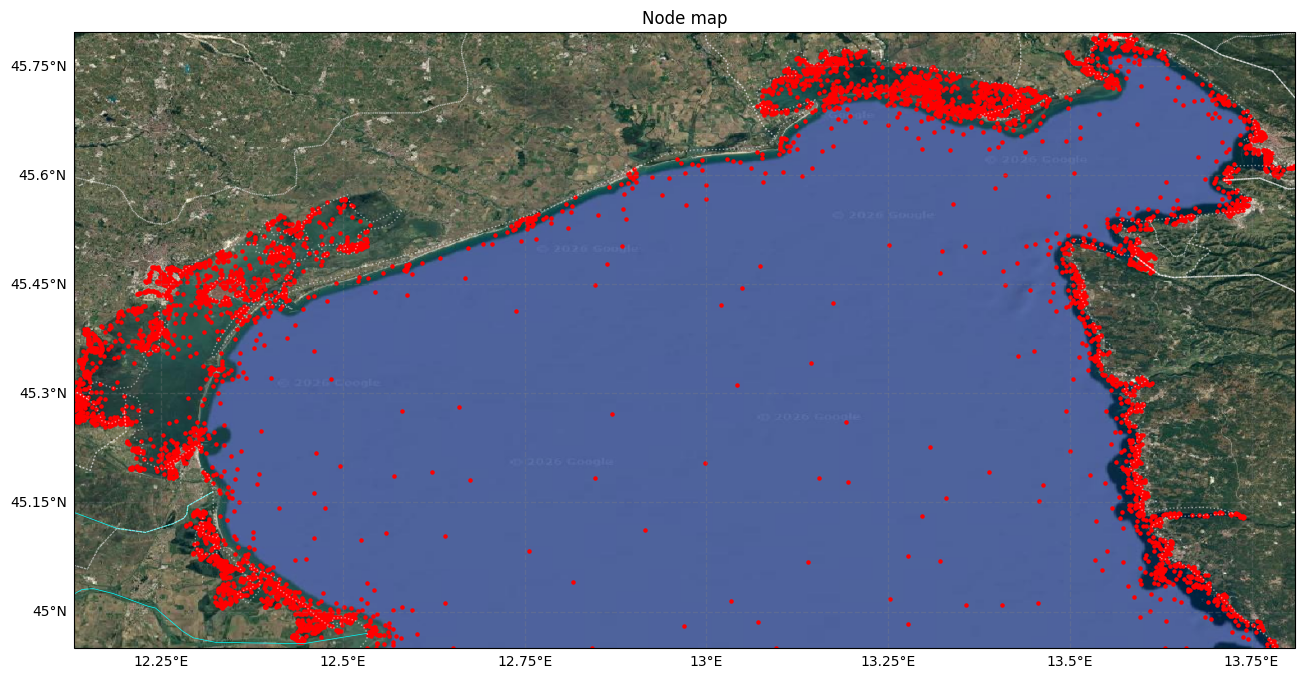

In [11]:
# Create figure and map
fig, ax = plt.subplots(figsize=(16, 8), subplot_kw={'projection': ccrs.PlateCarree()})
(lat_min, lat_max), (lon_min, lon_max) = (lat_vec.min(), lat_vec.max()), (lon_vec.min(), lon_vec.max())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

stamen_terrain = cimgt.GoogleTiles(style='satellite')
ax.add_image(stamen_terrain, 10)

ax.add_feature(cfeature.RIVERS, edgecolor='cyan', linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='white', alpha=0.5)
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='white', alpha=0.5)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.3, linestyle='--')
gl.top_labels = gl.right_labels = False

# Plot red dots
# Note: Ensure data is visible against the varied satellite background
sc = ax.scatter(lon_vec, lat_vec, cmap="viridis", c="r", s=5, marker='o', transform=ccrs.PlateCarree(), vmin=0.07, vmax=0.15)
# Increased 's' (size) slightly to make dots visible against satellite texture

plt.title(f'Node map')
plt.savefig("graphical_visualization.png", dpi=400)
plt.show()

## 05. Data Analysis

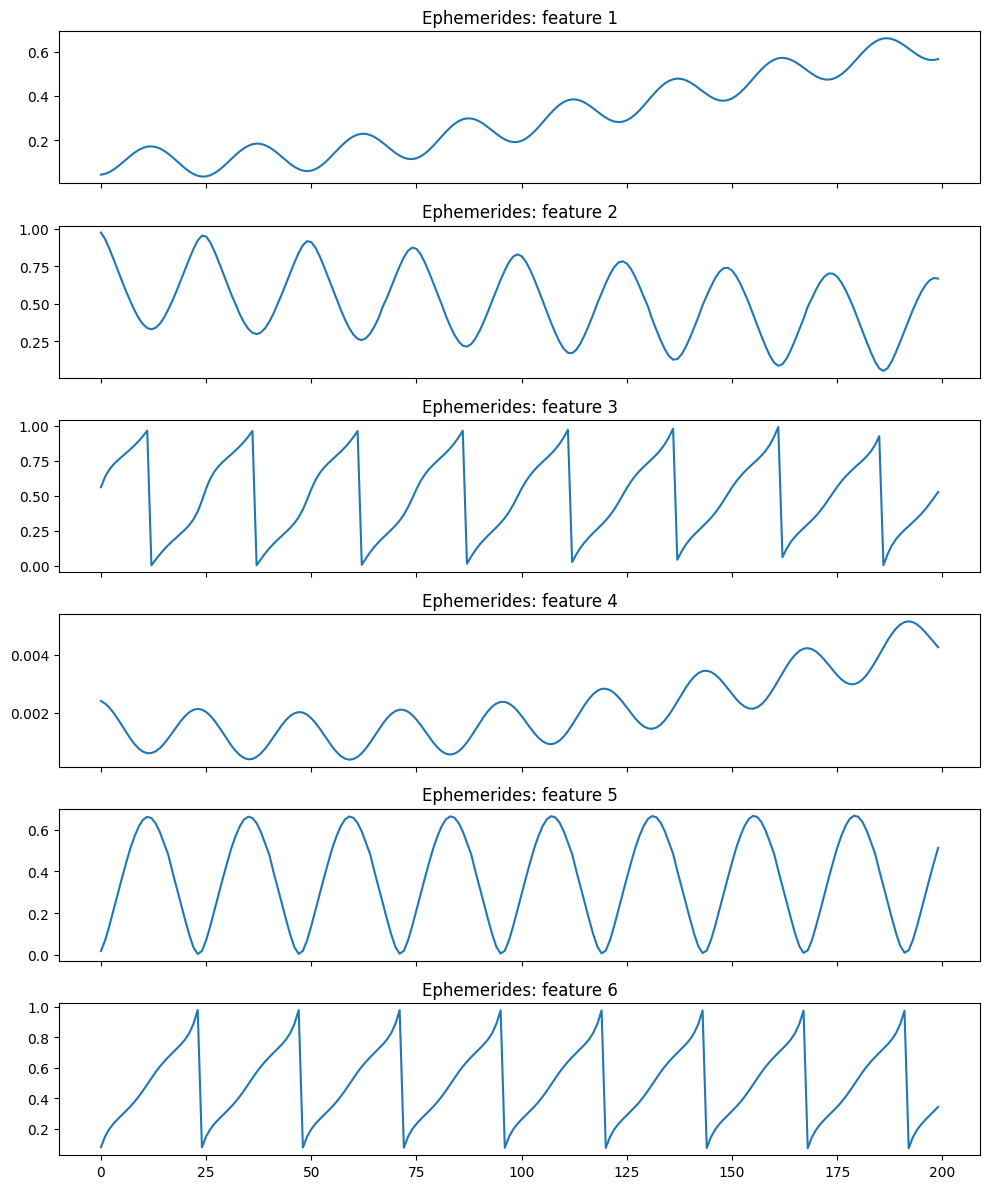

In [12]:
fig, axes = plt.subplots(6, 1, figsize=(10, 12), sharex=True)

for i in range(6):
    axes[i].plot(train_ephem[i, :200])
    axes[i].set_title(f"Ephemerides: feature {i+1}")
plt.tight_layout()
plt.show()

We can see that ephemerides are normalized and have a cyclical trend

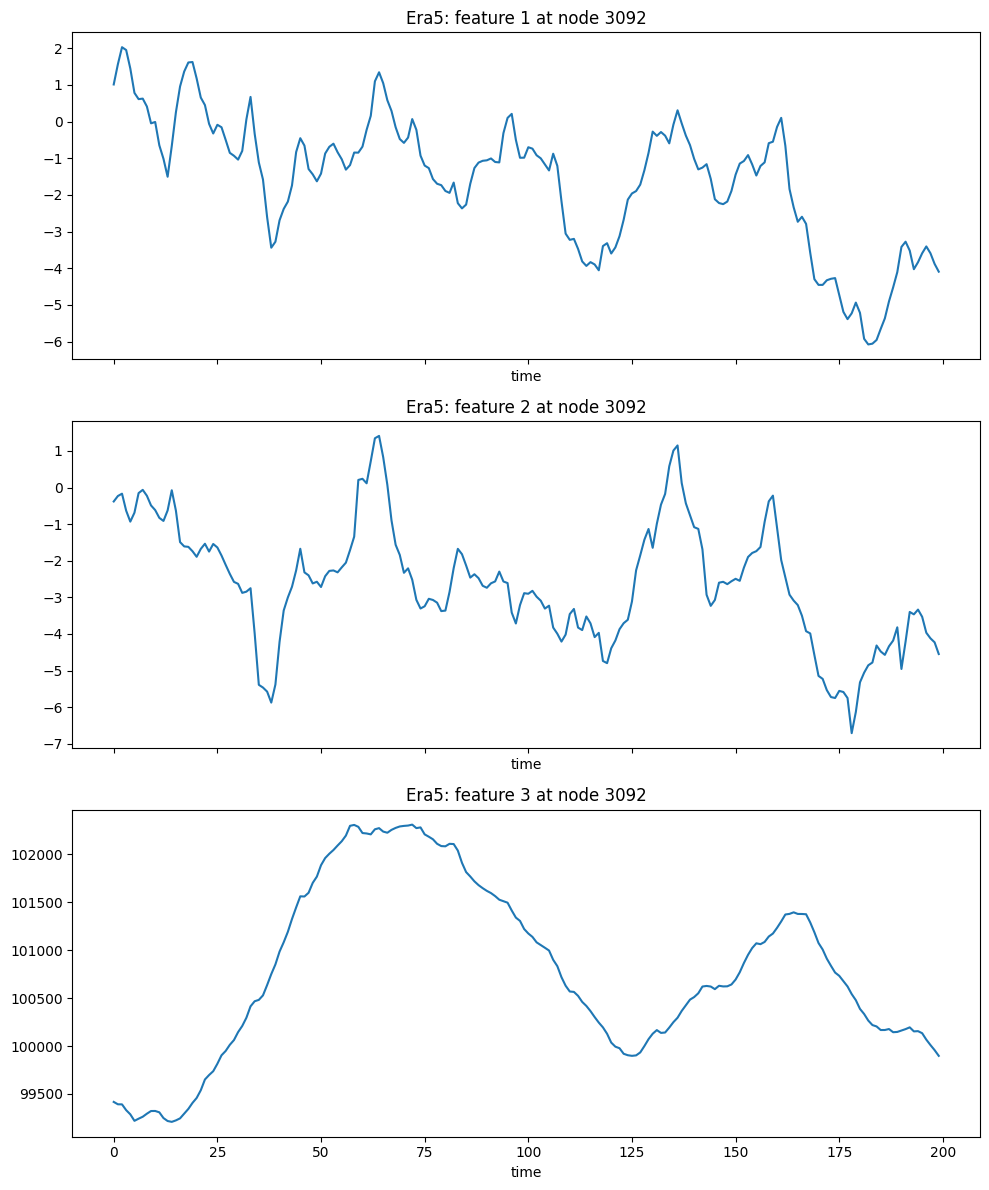

In [13]:
node_number = np.random.randint(np.shape(train_wl)[1])
era5_coords = get_era5_coord(lat_vec[node_number], lon_vec[node_number])

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for i in range(3):
    axes[i].plot(train_era5[i, :200, era5_coords[0], era5_coords[1]])
    axes[i].set_title(f"Era5: feature {i+1} at node {node_number}")
    axes[i].set_xlabel("time")
plt.tight_layout()
plt.show()

As you may observe, wind and especially pressure **are not normalized!!** Era5 features need to be normalised.

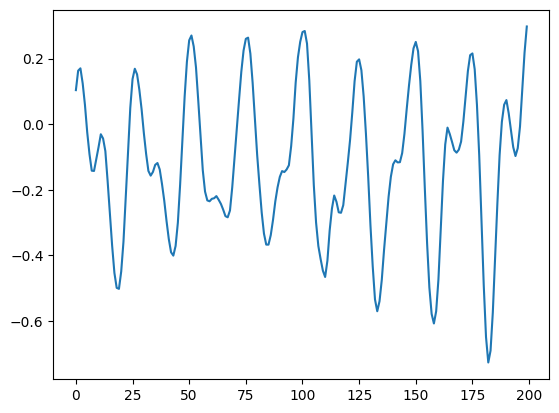

In [14]:
# Visualize a single node variability,
plt.plot(test_wl[:200, 0])
plt.show()

Water level time series show non-stationary behavior driven by:
- astronomical tides (regular oscillations),
- meteorological forcing (extreme events, surges).

Since magnitudes differ significantly across nodes, normalization is required before training.

## 06. Capturing periodicity

Although LSTMs can learn periodicity implicitly, providing sinusoidal time encodings helps the model
identify dominant frequencies more efficiently.
Here we encode:
- daily cycle (24h),
- annual cycle (seasonality).

Weekly and monthly components were tested but omitted as they were not improving the model performance and  to limit feature dimensionality and redundancy.

In [15]:
train_ts = np.array([datetime(*train_tvec[:, i].astype(int)).timestamp()
                     for i in range(train_tvec.shape[1])], dtype=np.float64)

test_ts  = np.array([datetime(*test_tvec[:, i].astype(int)).timestamp()
                     for i in range(test_tvec.shape[1])], dtype=np.float64)

print("Train time vector shape:", train_ts.shape)
print("Test time vector shape:", test_ts.shape)
print(train_ts[4])

Train time vector shape: (87648,)
Test time vector shape: (8784,)
1262318400.0


In [16]:
# creating periodicity from time to give the model access to important frequency features
def freq_set(timestamps):
    day = 24 * 60 * 60
    year = 365.2425 * day

    day_sin  = np.sin(timestamps * (2 * np.pi / day))
    day_cos  = np.cos(timestamps * (2 * np.pi / day))
    year_sin = np.sin(timestamps * (2 * np.pi / year))
    year_cos = np.cos(timestamps * (2 * np.pi / year))

    frequencies = np.column_stack((day_sin, day_cos,
                                #    week_sin, week_cos,
                                #    month_sin, month_cos,
                                   year_sin, year_cos
                                ))
    print(frequencies.shape)
    return frequencies

train_freq = freq_set(train_ts)
test_freq = freq_set(test_ts)

(87648, 4)
(8784, 4)


## 07. Creating train and validation split
Before normalising the era5 and the water level dataset we first fix the split between train, validation and test datasets, to avoid data leakage.
The validation set corresponds to the **last two years (2018–2019)** of the training period.

This choice ensures:
- strict temporal separation (no leakage),
- validation under realistic forecasting conditions,
- exposure to interannual variability.

Random splits are avoided due to strong temporal autocorrelation.

In [17]:
split_idx = train_ts.shape[0] - (8760*2)

val_wl    = train_wl[split_idx:]
val_ephem = train_ephem[: , split_idx:]
val_era5  = train_era5[: , split_idx:]
val_ts    = train_ts[split_idx:]
val_freq  = train_freq[split_idx:]

train_wl    = train_wl[:split_idx]
train_ephem = train_ephem[:, :split_idx]
train_era5  = train_era5[:, :split_idx]
train_ts    = train_ts[:split_idx]
train_freq  = train_freq[:split_idx]

#TODO try adding normalised lat e lon

print(val_wl.shape, val_ephem.shape, val_era5.shape, val_ts.shape, val_freq.shape)
print(train_wl.shape, train_ephem.shape, train_era5.shape, train_ts.shape, train_freq.shape)

(17520, 5000) (6, 17520) (3, 17520, 5, 9) (17520,) (17520, 4)
(70128, 5000) (6, 70128) (3, 70128, 5, 9) (70128,) (70128, 4)


In [18]:
datetime.fromtimestamp(val_ts[0])

datetime.datetime(2018, 1, 1, 0, 0)

In [19]:
datetime.fromtimestamp(val_ts[-1])

datetime.datetime(2019, 12, 31, 23, 0)

Validation Dataset spans across two years from 1/1/2018 to 31/12/2019

## 08. Data Normalisation

For the wind components u10 and v10, I used standard scaling in order to preserve the sign of the values, which is essential to maintain the information about wind direction (positive vs. negative).
For surface pressure, instead, the sign is not physically meaningful, and the variable mainly carries information through its relative magnitude. Therefore, I normalized pressure values to the [0, 1] range.

In [20]:
# scaler per feature
era5_scalers = [
    StandardScaler(),      # feature 0
    StandardScaler(),      # feature 1
    StandardScaler()   # feature 2
]

train_era5_norm = np.empty_like(train_era5, dtype=float)

for f in range(3):
    x = train_era5[f].reshape(-1, 1)
    train_era5_norm[f] = (era5_scalers[f].fit_transform(x).reshape(train_era5[f].shape))
val_era5_norm = np.empty_like(val_era5, dtype=float)
test_era5_norm = np.empty_like(test_era5, dtype=float)

In [21]:
val_era5_norm = np.empty_like(val_era5, dtype=float)
test_era5_norm = np.empty_like(test_era5, dtype=float)

for f in range(3):
    val_era5_norm[f] = era5_scalers[f].transform(
        val_era5[f].reshape(-1, 1)
    ).reshape(val_era5[f].shape)

    test_era5_norm[f] = era5_scalers[f].transform(
        test_era5[f].reshape(-1, 1)
    ).reshape(test_era5[f].shape)


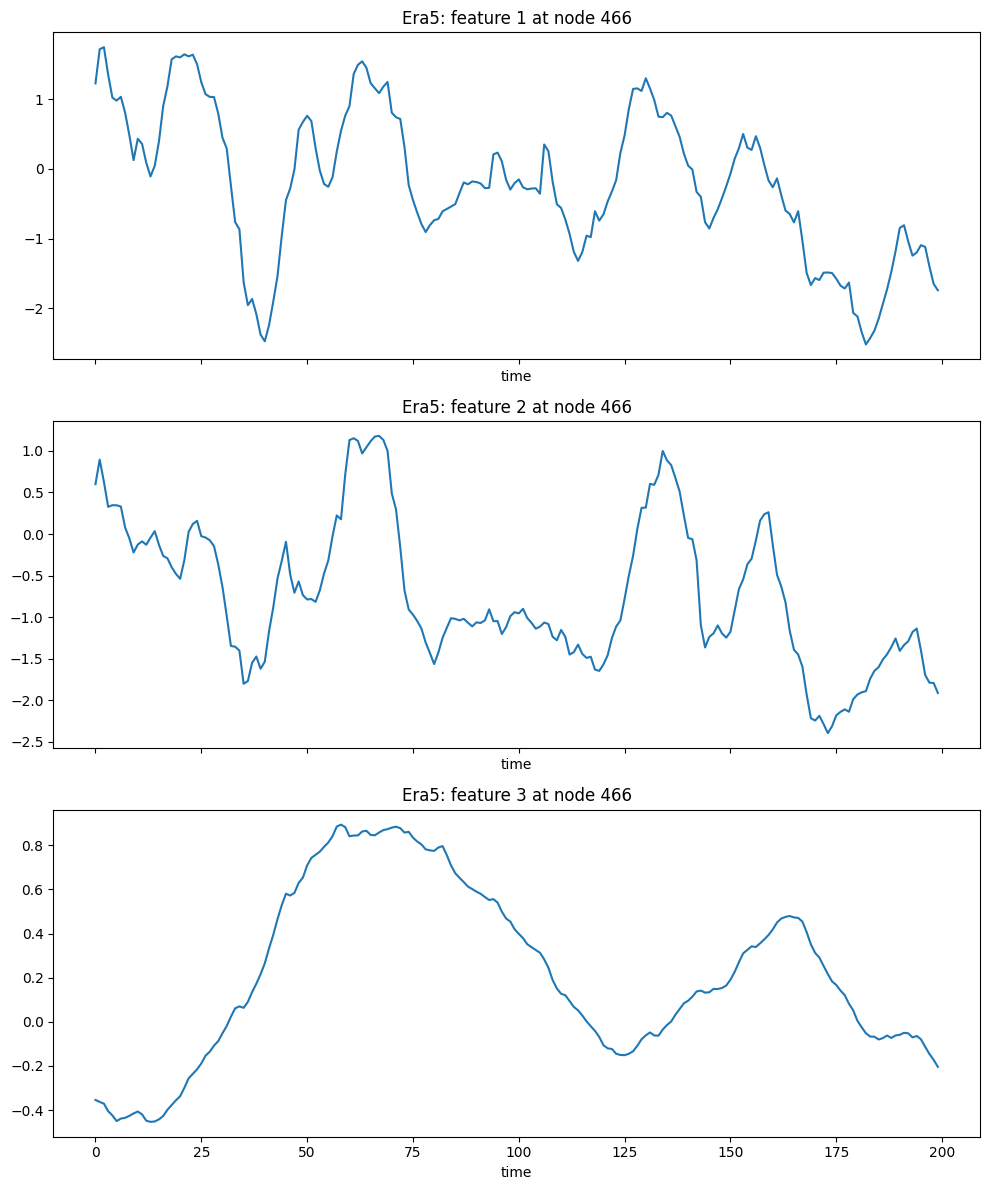

In [22]:
# plotting features after normalization
node_number = np.random.randint(np.shape(train_wl)[1])
era5_coords = get_era5_coord(lat_vec[node_number], lon_vec[node_number])

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for i in range(3):
    axes[i].plot(train_era5_norm[i, :200, era5_coords[0], era5_coords[1]])
    axes[i].set_title(f"Era5: feature {i+1} at node {node_number}")
    axes[i].set_xlabel("time")
plt.tight_layout()
plt.show()

In [23]:
wl_scaler = MinMaxScaler(feature_range=(0, 1))

train_wl_norm = wl_scaler.fit_transform(train_wl)
val_wl_norm   = wl_scaler.transform(val_wl)
test_wl_norm  = wl_scaler.transform(test_wl)

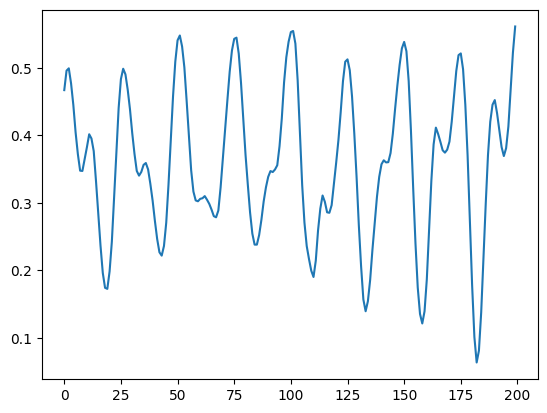

In [24]:
# Plotting water level for a single node after normalization
plt.plot(test_wl_norm[:200, 0])
plt.show()

## 09. Grouping datasets

Data are grouped into dictionaries to simplify downstream processing.
Each dictionary contains:
- static spatial information (lat, lon),
- dynamic predictors (ephemerides, ERA5, periodic features),
- target variable (water level).

In [25]:
# organising datasets for easier recall during data windowings
train_df = {
    "lat": lat_vec,
    "lon": lon_vec,
    "wl": train_wl_norm,
    "ephem": train_ephem,
    "era5": train_era5_norm,
    "ts": train_ts,
    "freq": train_freq}
val_df = {
    "lat": lat_vec,
    "lon": lon_vec,
    "wl": val_wl_norm,
    "ephem": val_ephem,
    "era5": val_era5_norm,
    "ts": val_ts,
    "freq": val_freq}
test_df = {
    "lat": lat_vec,
    "lon": lon_vec,
    "wl": test_wl_norm,
    "ephem": test_ephem,
    "era5": test_era5_norm,
    "ts": test_ts,
    "freq": test_freq}

## 10. Data Windowing

Each training sample consists of:
- an input window of `input_width` past hours,
- a prediction horizon of `label_width` hours,
- a shift that enforces causality.

For each window:
- all predictors are provided for the input period,
- only the water level at the prediction time is used as label.

Windows are efficiently generated sequentially without shuffling to preserve temporal order.

Latitude and longitude were excluded to reduce feature dimensionality and to prevent the introduction of unnecessary noise into the model.

In [26]:
class WindowGenerator():
    def __init__(self, input_width, label_width, shift,
                 train_df, val_df, test_df, batch_size=32,
                 label_columns=None,
                 feature_columns=None,
                 node_ids=None):
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df
        self.batch_size = batch_size

        self.label_columns = label_columns or ["wl"]
        self.feature_columns = feature_columns or [
            "ephem1", "ephem2", "ephem3", "ephem4", "ephem5", "ephem6", "wind0",
            "wind1", "pressure", "freq1", "freq2", "freq3", "freq4"
        ]

        self.node_ids = node_ids
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift

        self.total_window_size = input_width + shift
        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        self.label_start = self.total_window_size - self.label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

In [27]:
def _build_inputs_and_labels(self, data):
    T, N = data["wl"].shape

    if self.node_ids is None:
        node_ids = np.arange(N)
    else:
        node_ids = np.array(self.node_ids)

    n_nodes = len(node_ids)

    lat = data["lat"][node_ids]
    lon = data["lon"][node_ids]
    wl = data["wl"][:, node_ids]

    era5_node = np.empty((T, n_nodes, 3), dtype=np.float32)
    for j, node in enumerate(node_ids):
        r, c = get_era5_coord(data["lat"][node], data["lon"][node])
        era5_node[:, j, 0] = data["era5"][0, :, r, c]
        era5_node[:, j, 1] = data["era5"][1, :, r, c]
        era5_node[:, j, 2] = data["era5"][2, :, r, c]

    lat = np.tile(lat[None, :, None], (T, 1, 1))
    lon = np.tile(lon[None, :, None], (T, 1, 1))
    ephem = np.tile(data["ephem"].T[:, None, :], (1, n_nodes, 1))
    freq  = np.tile(data["freq"][:, None, :], (1, n_nodes, 1))

    X = np.concatenate([ephem, era5_node, freq], axis=-1)
    y = wl

    return X.astype(np.float32), y.astype(np.float32)

WindowGenerator._build_inputs_and_labels = _build_inputs_and_labels

In [28]:
def split_window(self, data):
    inputs = data[:, self.input_slice, :, :-1]
    labels = data[:, self.labels_slice, :, -1]

    # Use dynamic shapes (TensorFlow graph-safe)
    shape = tf.shape(inputs)
    B = shape[0]
    T = shape[1]
    N = shape[2]
    F = shape[3]

    inputs = tf.reshape(inputs, (B * N, T, F))
    labels = tf.reshape(labels, (B * N, self.label_width))

    return inputs, labels

WindowGenerator.split_window = split_window

In [29]:
def make_dataset(self, data):
    features, labels = self._build_inputs_and_labels(data)
    data_with_label = np.concatenate([features, labels[..., None]], axis=-1)

    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=data_with_label,
        targets=None,
        sequence_length=self.total_window_size,
        sequence_stride=1,
        shuffle=False,  # data cannot be shuffled due to time dependencies
        batch_size=self.batch_size
    )

    return ds.map(self.split_window)

WindowGenerator.make_dataset = make_dataset

In [30]:
@property
def train(self):
    return self.make_dataset(self.train_df)

@property
def val(self):
    return self.make_dataset(self.val_df)

@property
def test(self):
    return self.make_dataset(self.test_df)

@property
def example(self):
    """Get and cache an example batch of `inputs, labels` for plotting."""
    result = getattr(self, '_example', None)
    if result is None:
        # No example batch was found, so get one from the `.train` dataset
        result = next(iter(self.train))
        # And cache it for next time
        self._example = result
    return result

WindowGenerator.train = train
WindowGenerator.val = val
WindowGenerator.test = test
WindowGenerator.example = example

In [31]:
def plot(self, model=None, plot_feature_index=0, feature_name=None,
        node_index=0, max_subplots=3):
    """
    plot_feature_index: index of input feature in X (0..F-1)
    node_index: which sample in the batch to plot
    """
    inputs, labels = self.example
    # inputs: (batch_nodes, time, features)
    # labels: (batch_nodes, label_width)

    plt.figure(figsize=(12, 8))
    max_n = min(max_subplots, inputs.shape[0])

    for n in range(max_n):
        idx = node_index + n
        if idx >= inputs.shape[0]:
            break

        plt.subplot(max_n, 1, n + 1)

        if feature_name is None:
            feature_name = self.feature_columns[plot_feature_index]

        # plot inputs
        plt.plot(
            self.input_indices,
            inputs[idx, :, plot_feature_index],
            label=feature_name,
            marker=".",
            zorder=-10
        )

        # plot labels
        plt.scatter(
            self.label_indices,
            labels[idx, :],
            edgecolors="k",
            label="Water Level",
            c="#2ca02c",
            s=64
        )

        if model is not None:
            predictions = model(inputs)
            plt.scatter(
                self.label_indices,
                predictions[idx, :],
                marker="X",
                edgecolors="k",
                label="Predictions",
                c="#ff7f0e",
                s=64
            )

        if n == 0:
            plt.legend()

    plt.xlabel("Time [h]")
    plt.show()

WindowGenerator.plot = plot

Here a demonstration of how to instantiate the `WindowGenerator` by selecting a random subset of nodes
(here limited to a single node).

To inspect the structure of the generated temporal windows, the following aspects are verified:
- the **shapes of inputs and labels** produced by the windowed dataset,
- the **total number of input features** provided to the model,

Finally, selected input features (ephemerides and ERA5 surface pressure) can be visualized within
a temporal window.

In [32]:
subset_nodes = np.random.choice(5000, size=1, replace=False)

wg = WindowGenerator(
    input_width=72,
    label_width=1,
    shift=1,
    batch_size=32,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    node_ids=subset_nodes,
)

In [33]:
inputs, labels = next(iter(wg.train))
print(inputs.shape)  # (batch, 24, 20, F)
print(labels.shape)  # (batch, 1, 20)

(32, 72, 13)
(32, 1)


Inputs shape: (32, 72, 13)
Labels shape: (32, 1)
Num features: 13
Feature columns: ['ephem1', 'ephem2', 'ephem3', 'ephem4', 'ephem5', 'ephem6', 'wind0', 'wind1', 'pressure', 'freq1', 'freq2', 'freq3', 'freq4']


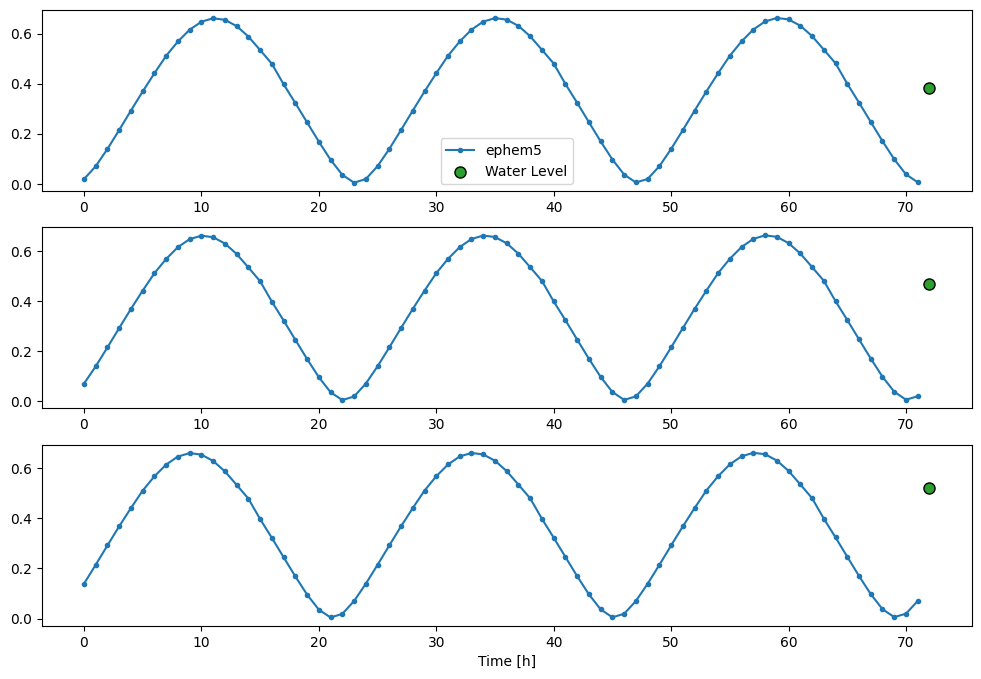

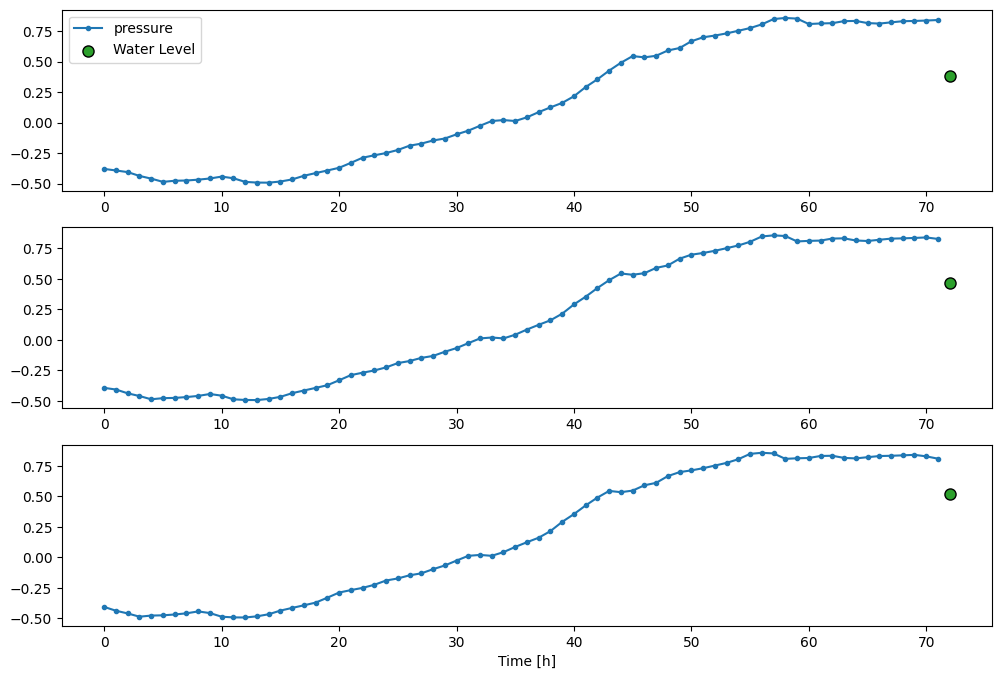

In [34]:
print("Inputs shape:", inputs.shape)  # (batch, 24, 5000, F)
print("Labels shape:", labels.shape)  # (batch, 1, 5000)

# Check input feature dimension
print("Num features:", inputs.shape[-1])
print("Feature columns:", wg.feature_columns)

# plot feature index 0 (lat) for node 0
wg.plot(plot_feature_index=4, node_index=0)

# plot feature index corresponding to pressure
# (ephem=0..5, era5=6..8, freq=9..12)
# pressure is index 8
wg.plot(plot_feature_index=8, node_index=0)

## 11. Model definition

An **LSTM** architecture was initially tested; however, it produced inferior results.  
Consequently, a **GRU** model was implemented, leading to improved performance and better overall results.

The model consists of:
- two stacked **GRU** layers to capture multi-scale temporal dependencies,
- a dense projection layer,
- dropout for regularization,
- a final linear output for water level regression.

The architecture is intentionally compact to limit overfitting, given the strong
temporal autocorrelation of the data.

In [35]:
def build_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(64, return_sequences=True),
        Dropout(0.2),
        GRU(32),
        Dense(1)
    ])
    return model

## 12. Model training

In [36]:
MAX_EPOCHS = 25

def compile_and_fit(model, window, patience=5):
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    restore_best_weights=True,
                                                    min_delta = 0.0,
                                                    )

  model.compile(loss=tf.losses.MSE,
                optimizer=tf.optimizers.Adam(),
                metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")])

  history = model.fit(window.train, epochs=MAX_EPOCHS,
                      validation_data=window.val,
                      callbacks=[early_stopping])
  return history

**Training Setup**:
- **Loss**: Mean Squared Error (MSE)
- **Metric**: Root Mean Squared Error (RMSE)
- **Optimizer**: Adam
- **Early stopping** prevents overfitting and restores best weights

Training is performed on sliding windows, not individual timestamps, ensuring
temporal context is always available to the model.

In [37]:
features = 13

In [38]:
#subset_nodes = np.random.choice(5000, size=1, replace=False)
subset_nodes = [1] #fixed for better reproducibility of results

timesteps = 72
wide_window = WindowGenerator(
    input_width=timesteps,
    label_width=1,
    train_df=train_df,
    val_df=val_df, 
    test_df=test_df,
    batch_size=32,
    shift=1,
    node_ids=subset_nodes)

model = build_model(input_shape=(timesteps, features))
history = compile_and_fit(model, wide_window)
model.evaluate(wide_window.test)
model.evaluate(wide_window.test)

Epoch 1/25
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 33s 13ms/step - loss: 0.0172 - rmse: 0.1256 - val_loss: 0.0171 - val_rmse: 0.1307
Epoch 2/25
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - loss: 0.0045 - rmse: 0.0668 - val_loss: 0.0141 - val_rmse: 0.1187
Epoch 3/25
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - loss: 0.0039 - rmse: 0.0627 - val_loss: 0.0093 - val_rmse: 0.0967
Epoch 4/25
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - loss: 0.0037 - rmse: 0.0606 - val_loss: 0.0037 - val_rmse: 0.0604
Epoch 5/25
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - loss: 0.0032 - rmse: 0.0560 - val_loss: 0.0039 - val_rmse: 0.0623
Epoch 6/25
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - loss: 0.0030 - rmse: 0.0546 - val_loss: 0.0032 - val_rmse: 0.0562
Epoch 7/25
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - loss: 0.0029 - rmse: 0.0534 - val_loss: 0.0030 - val_rmse: 0.0550
Epoch 8/25
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - loss: 0.0027 - rmse: 0.0516 - val_loss: 0.0028 - val_rmse: 0.0530
Epoch 9/

[0.002113427734002471, 0.045972030609846115]

A temporal window of **72 time steps** was selected as it provided the best trade-off between capturing relevant temporal dependencies and maintaining model generalization.  

Shorter windows were not sufficient to fully capture the delayed hydrological responses and longer-term temporal patterns present in the data, while longer windows increased model complexity and led to diminishing returns or overfitting.  

Empirical evaluation across multiple window sizes showed that a window length of 72 consistently achieved the lowest validation error, making it the optimal choice for this task.

## 13. Model Evaluation

In [39]:
def display_history(history):
    history_dict = history.history
    epochs = range(1, len(history_dict['loss']) + 1)

    # ----- Loss (MSE) -----
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history_dict['loss'], label='Training MSE')
    plt.plot(epochs, history_dict['val_loss'], label='Validation MSE')
    plt.grid(True)
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.title('Loss (MSE) during training')
    plt.legend()
    plt.show()

    # ----- RMSE -----
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history_dict['rmse'], label='Training RMSE')
    plt.plot(epochs, history_dict['val_rmse'], label='Validation RMSE')
    plt.grid(True)
    plt.xlabel('Epoch')
    plt.ylabel('RMSE')
    plt.title('RMSE during training')
    plt.legend()
    plt.show()


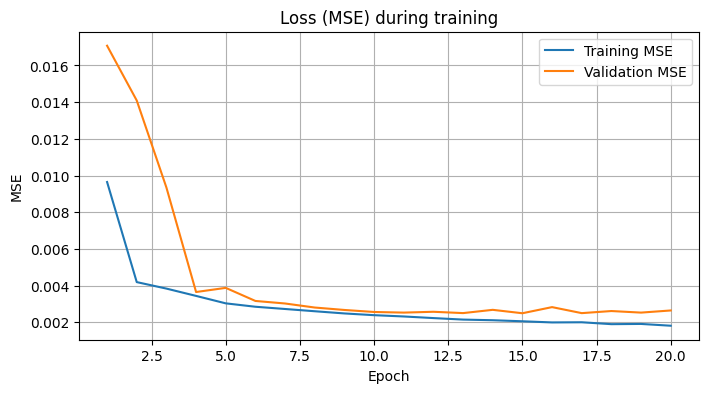

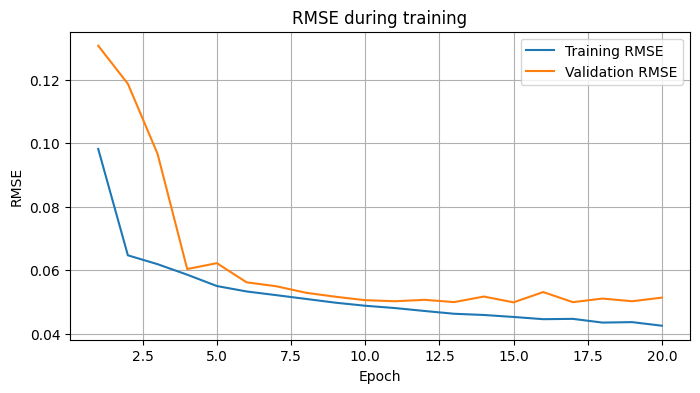

In [40]:
display_history(history)

The training and validation loss decrease steadily and remain close to each other,
indicating that the model is learning meaningful temporal patterns without severe overfitting.

In [44]:
def denorm_minmax(x_norm, scaler):
    data_min = scaler.data_min_
    data_max = scaler.data_max_
    return x_norm * (data_max - data_min) + data_min

y_true_norm = []
y_pred_norm = []

for x_batch, y_batch in wide_window.test:
    preds = model.predict(x_batch, verbose=0)
    y_true_norm.append(y_batch.numpy())
    y_pred_norm.append(preds)

y_true_norm = np.concatenate(y_true_norm, axis=0)
y_pred_norm = np.concatenate(y_pred_norm, axis=0)

y_true_denorm = denorm_minmax(y_true_norm, wl_scaler)
y_pred_denorm = denorm_minmax(y_pred_norm, wl_scaler)

rmse_denorm = np.sqrt(np.mean((y_pred_denorm - y_true_denorm) ** 2))
print(f"Model's RMSE: {rmse_denorm:.4f}")

Model's RMSE: 0.0837


In [42]:
persistence_baseline = RMSE(test_wl[:-1],test_wl[1:])
print(f"persistence baseline: {persistence_baseline:.4f}")

persistence baseline: 0.0859


This baseline is difficult to beat in highly autocorrelated systems and provides
a meaningful reference for model skill.

In [43]:
improvement = (persistence_baseline - rmse_denorm) / persistence_baseline
print(f"The model performs better than the persistence baseline of approximately",
      f"{improvement:.2%}, where improvement is calculated as",
      f"(baseline_rmse - model_rmse) / baseline_rmse.")

The model performs better than the persistence baseline of approximately 2.53%, where improvement is calculated as (baseline_rmse - model_rmse) / baseline_rmse.
